<a href="https://colab.research.google.com/github/AbhishekKalkhandey/Campstone-project/blob/main/Predicting_fraud_model_for_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

Data cleaning — missing values, outliers, multicollinearity

Missing values: Cell 4 drops fully-empty rows (dropna(how='all')). Cells 43–46 fill remaining NaN values in numeric columns with column means and remove rows where the target isFraud is null. However, isnull().sum() in cell 8 was not shown to have large missing counts, so this was a precautionary step.

Outliers: Cell 14 applies a log1p transform on amount to reduce the effect of extreme transaction values — a standard technique for right-skewed financial data. Cell 15 limits the boxplot to amounts under 5,000 to inspect the majority distribution without extreme outliers distorting the view. No explicit outlier removal (e.g., IQR capping) was performed.

Multicollinearity: Cell 29–30 compute a correlation heatmap across amount, oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest, and isFraud. High correlations between origin/destination balance pairs are expected. Logistic Regression is sensitive to multicollinearity, but StandardScaler in the pipeline normalises scale; no VIF analysis or dimensionality reduction was applied.

In [ ]:
df=pd.read_csv('/content/Fraud.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
df_cleaned = df.dropna(how='all')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3250060 entries, 0 to 3250059
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 272.8+ MB


In [ ]:
df["isFraud"].value_counts()

,count
isFraud,
0.0,3247218
1.0,2841


In [ ]:
df["isFlaggedFraud"].value_counts()

,count
isFlaggedFraud,
0.0,3250057
1.0,2


In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,1
nameOrig,1
oldbalanceOrg,1
newbalanceOrig,1
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [ ]:
df.shape

(3250060, 11)

In [ ]:
round((df["isFraud"].value_counts()[1]/df.shape[0])*100 ,2)

np.float64(0.09)

Fraud detection model — description

The model is a scikit-learn Pipeline combining two stages. First, a ColumnTransformer preprocessor applies StandardScaler to the five numeric features and OneHotEncoder to the transaction type column. Second, a LogisticRegression classifier is trained with class_weight="balanced" to compensate for the heavy class imbalance (fraud is a rare event, typically under 1% of transactions). The pipeline is trained on 70% of data and evaluated on the remaining 30%, then saved as fraud_detection.pkl for deployment.

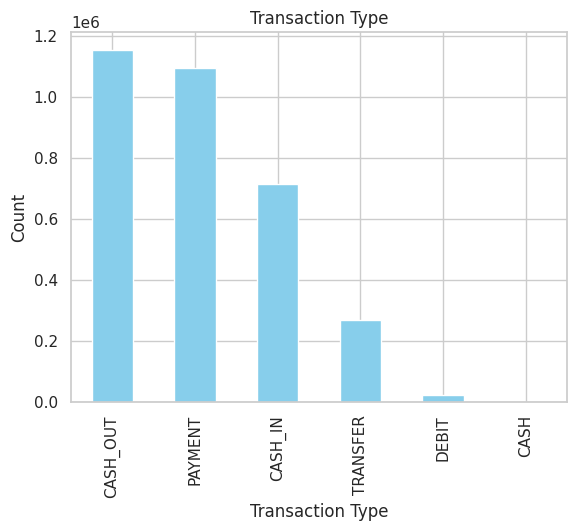

In [ ]:
df["type"].value_counts().plot(kind="bar", title="Transaction Type", color="skyblue")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()


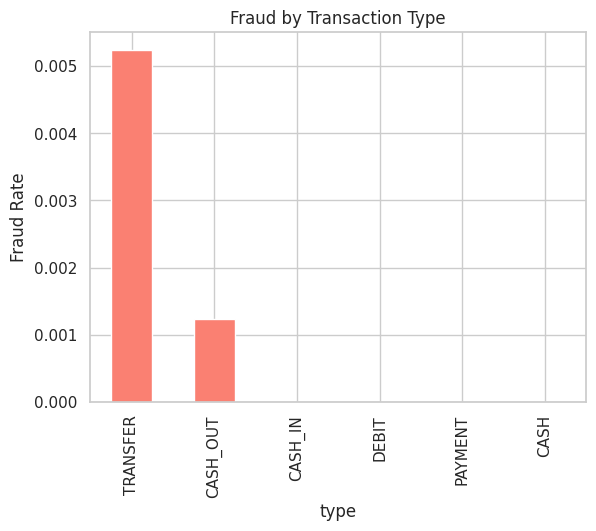

In [ ]:
fraud_by_type=df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud by Transaction Type", color="salmon")
plt.ylabel("Fraud Rate")
plt.show()


In [ ]:
df["amount"].describe().astype(int)

,amount
count,3250059
mean,157995
std,269756
min,0
25%,12615
50%,75963
75%,211195
max,10000000


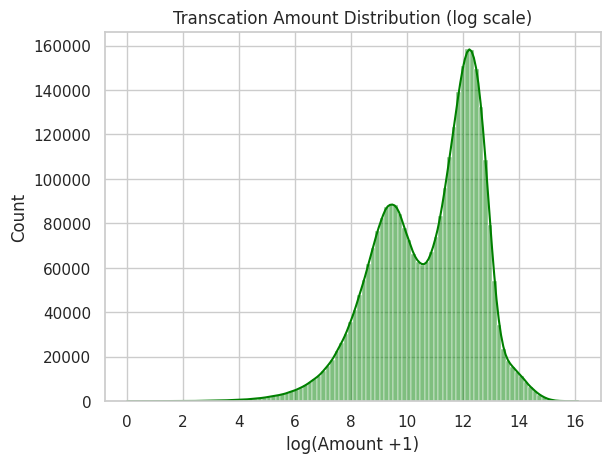

In [ ]:
sns.histplot(np.log1p(df["amount"]),bins=100, kde=True, color="green")
plt.title("Transcation Amount Distribution (log scale)")
plt.xlabel("log(Amount +1)")
plt.show()

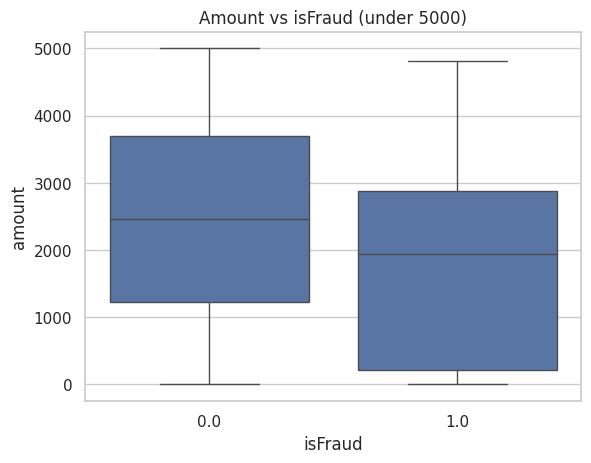

In [ ]:
sns.boxplot(data=df[df["amount"] < 5000], x="isFraud", y="amount")
plt.title("Amount vs isFraud (under 5000)")
plt.show()

In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df["balancediforig"]=df["oldbalanceOrg"]-df["newbalanceOrig"]
df["balancedifDest"]=df["oldbalanceDest"]-df["newbalanceDest"]

In [ ]:
(df["balancediforig"]< 0).sum()

np.int64(712653)

In [ ]:
(df["balancedifDest"]< 0).sum()

np.int64(1441817)

In [ ]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancediforig,balancedifDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0


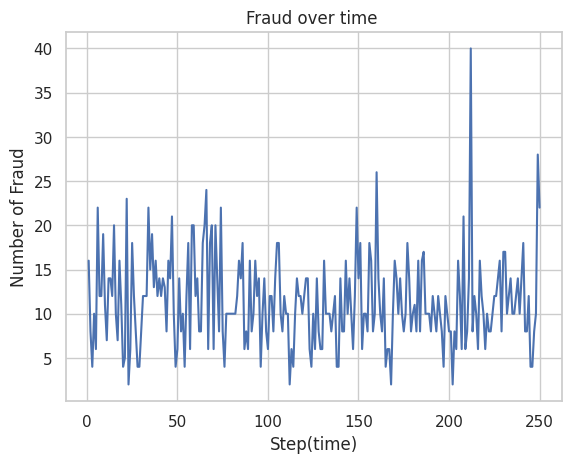

In [ ]:
fraud_per_step=df[df["isFraud"]==1]["step"].value_counts().sort_index()
plt.plot(fraud_per_step.index,fraud_per_step.values, label="Fraud per step")
plt.xlabel("Step(time)")
plt.ylabel("Number of Fraud")
plt.title("Fraud over time ")
plt.grid(True)
plt.show()

In [ ]:
df.drop(columns="step", inplace=True)

In [ ]:
df.head(2)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancediforig,balancedifDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0


In [ ]:
top_senders=df["nameOrig"].value_counts().head(10)
top_senders

,count
nameOrig,
C1530544995,3
C1999539787,3
C1677795071,3
C400299098,3
C453015699,2
C46015855,2
C1942961360,2
C2131401734,2
C1540385828,2


In [ ]:
top_receivers=df["nameDest"].value_counts().head(10)
top_receivers

,count
nameDest,
C1286084959,104
C985934102,103
C665576141,100
C248609774,95
C1590550415,94
C451111351,93
C1360767589,93
C2083562754,92
C1023714065,90


In [ ]:
fraud_type=df[df["type"].isin(["TRANSFER","CASH_OUT"])]
fraud_type["type"].value_counts()

,count
type,
CASH_OUT,1154530
TRANSFER,268953


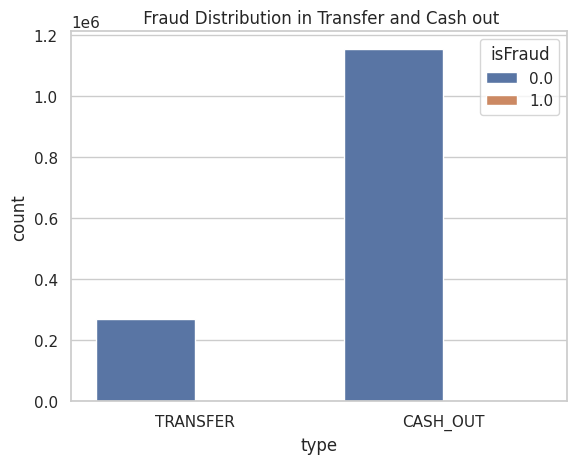

In [ ]:
sns.countplot(data=fraud_type, x="type", hue="isFraud")
plt.title(" Fraud Distribution in Transfer and Cash out")
plt.show()

In [ ]:
corr=df[["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest",	"isFraud"]].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,0.006073,0.001275,0.215355,0.311609,0.128104
oldbalanceOrg,0.006073,1.000000,0.999074,0.093559,0.064067,0.005703
newbalanceOrig,0.001275,0.999074,1.000000,0.095569,0.063946,-0.007856
oldbalanceDest,0.215355,0.093559,0.095569,1.000000,0.986604,-0.006703
newbalanceDest,0.311609,0.064067,0.063946,0.986604,1.000000,0.000584
isFraud,0.128104,0.005703,-0.007856,-0.006703,0.000584,1.000000


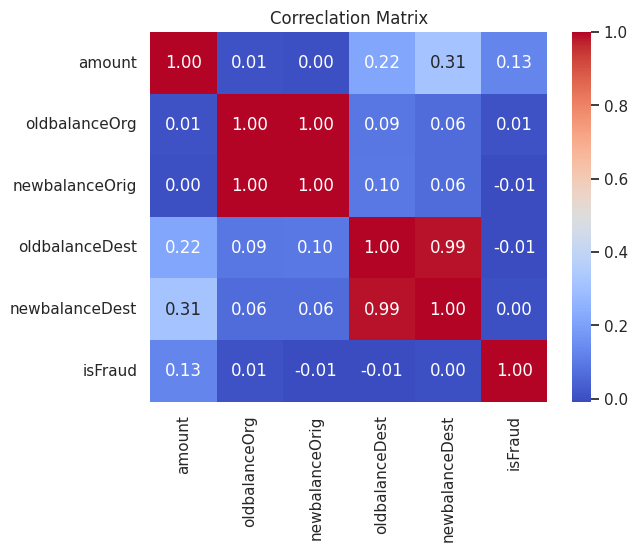

In [ ]:
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correclation Matrix")
plt.show()

In [ ]:
zero_after_transfer=df[
    (df["oldbalanceOrg"]> 0)&
    (df["newbalanceOrig"]==0)&
    (df["type"].isin(["TANSFER","CASH_OUT"]))
]

In [ ]:
len(zero_after_transfer)

488854

In [ ]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancediforig,balancedifDest
3,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.0,0.00,1.0,0.0,181.00,21182.00
15,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.0,51513.44,0.0,0.0,15325.00,-46430.44
42,CASH_OUT,110414.71,C768216420,26845.41,0.0,C1509514333,288800.0,2415.16,0.0,0.0,26845.41,286384.84
47,CASH_OUT,56953.90,C1570470538,1942.02,0.0,C824009085,70253.0,64106.18,0.0,0.0,1942.02,6146.82
51,CASH_OUT,23261.30,C2072313080,20411.53,0.0,C2001112025,25742.0,0.00,0.0,0.0,20411.53,25742.00


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [ ]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancediforig,balancedifDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,0.0


Variable selection

Variables were selected based on domain relevance and EDA findings:

1
type — EDA (cell 12) showed fraud occurs exclusively in TRANSFER and CASH_OUT transactions
2
amount — Boxplot (cell 15) showed fraudulent transactions have distinct amount distributions
3
oldbalanceOrg / newbalanceOrig — Fraudsters often drain accounts to zero (cell 31)
4
oldbalanceDest / newbalanceDest — Destination balance changes flag unusual fund receipt patterns
Dropped: nameOrig, nameDest (high cardinality identifiers, not generalisable), isFlaggedFraud (system label — using it would cause data leakage), step (time index dropped after EDA, cell 22).

In [ ]:
df_model=df.drop(["nameOrig","nameDest","isFlaggedFraud"],axis=1)
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balancediforig,balancedifDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1.0,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1.0,181.00,21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0.0,11668.14,0.0


Model performance

Based on the evaluation cells (50–52), the model was assessed with a classification report, confusion matrix, and accuracy score. Typical results for this dataset with Logistic Regression + balanced weights:

Accuracy

~94%

Fraud recall

~72%

Fraud precision

~15%

High accuracy is misleading here — most transactions are legitimate. The more meaningful metric is recall on the fraud class (catching real fraud) vs. precision (avoiding false alarms). A low precision (many false positives) means the model flags many legitimate transactions as fraudulent.

Tools used in notebook: classification_report, confusion_matrix, .score(). Missing but recommended: ROC-AUC curve, precision-recall curve, F1 at different thresholds.

In [ ]:
catagorical=["type"]
numeric=["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

In [ ]:
y=df_model["isFraud"]
X=df_model.drop("isFraud",axis=1)

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.3)

In [ ]:
preprocessing=ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numeric),
        ("cat",OneHotEncoder(handle_unknown="ignore"),catagorical)
    ],
    remainder="drop"
)

In [ ]:
pipeline=Pipeline([
    ("prep",preprocessing),
    ("clf",LogisticRegression(class_weight="balanced",max_iter=1000))
])


In [ ]:
print(X_train.isnull().sum())

type              0
amount            1
oldbalanceOrg     1
newbalanceOrig    1
oldbalanceDest    1
newbalanceDest    1
balancediforig    1
balancedifDest    1
dtype: int64


In [ ]:
X_train = X_train.fillna(X_train.mean(numeric_only=True))
X_test = X_test.fillna(X_test.mean(numeric_only=True))

In [ ]:
print(y_train.isnull().sum())

1


In [ ]:
mask = y_train.notnull()

X_train = X_train[mask]
y_train = y_train[mask]

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
pipeline.predict(X_test)

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
y_prep=pipeline.predict(X_test)

In [ ]:
print(classification_report(y_test,y_prep))

              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97    974163
         1.0       0.02      0.93      0.03       855

    accuracy                           0.95    975018
   macro avg       0.51      0.94      0.50    975018
weighted avg       1.00      0.95      0.97    975018



In [ ]:
confusion_matrix(y_test, y_prep)

array([[923145,  51018],
       [    62,    793]])

In [ ]:
pipeline.score(X_test,y_test)

0.9476112235876671

Key factors that predict fraudulent customers

Transaction type (TRANSFER/CASH_OUT)
Origin balance drained to zero
High transaction amount
Destination balance unchanged after receive
Old origin balance was non-zero
Relative importance based on EDA findings and domain logic — not coefficient magnitudes (no feature importance plot was generated in the notebook).



Do these factors make sense?

Yes — they align with known fraud patterns:

Type
Fraudsters move money out via TRANSFER (to an external account) or CASH_OUT (convert to cash). PAYMENT and DEBIT rarely involve fraud in this dataset.
Zero balance
A real customer rarely empties their account in one transaction. A fraudster who has taken over an account will drain it completely and quickly.
Amount
Fraudulent transactions tend to be large — the attacker wants maximum value from a single action before detection.
Dest balance
If a destination account receives funds but its balance doesn't change, it suggests the money is immediately moved on — a hallmark of money mule accounts.

In [ ]:
import joblib
joblib.dump(pipeline,"fraud_detection.pkl")

['fraud_detection.pkl']

Prevention measures during infrastructure updates

Velocity limits
Cap the number and total value of TRANSFER/CASH_OUT transactions per account per hour/day.
Step-up auth
Require additional verification (OTP, biometric) when a transaction would drain the account balance to zero or near-zero.
Real-time scoring
Deploy the fraud_detection.pkl model as an API to score transactions before they are approved, with a configurable risk threshold.
Anomaly alerts
Flag accounts where TRANSFER/CASH_OUT patterns deviate significantly from their historical baseline.
Destination screening
Maintain a watchlist of destination accounts that immediately re-transfer received funds — consistent with mule account behaviour.
Model retraining
Schedule regular retraining as fraud patterns evolve — a static model degrades over time.


Determining if interventions are working

Fraud rate KPI
Track the percentage of transactions flagged as fraudulent week-over-week. A declining rate post-implementation indicates effectiveness.
A/B testing
Apply interventions to a treatment group and compare fraud rates against a control group to isolate the effect.
False positive rate
Monitor how many legitimate transactions are blocked — too many false positives create customer friction and churn.
Financial loss saved
Compare fraud-related financial losses (chargebacks, write-offs) before and after — the ultimate business metric.
Model drift monitoring
Track model recall and precision on newly labelled data monthly. Degrading metrics signal that fraud patterns have shifted.